# Klasifikasi Status Stunting Balita Menggunakan Random Forest & XGBoost

**Metodologi:** CRISP-DM (Cross Industry Standard Process for Data Mining)
**Algoritma:** Random Forest, XGBoost
**Standar Pelabelan:** Z-Score TB/U — WHO / Kemenkes RI 2023

| Kategori | Rentang Z-Score |
|---|---|
| Severely Stunted (Sangat Pendek) | Z-Score < -3 SD |
| Stunted (Pendek) | -3 SD ≤ Z-Score < -2 SD |
| Normal | -2 SD ≤ Z-Score ≤ +3 SD |
| Tinggi | Z-Score > +3 SD |

> **Catatan struktur:** Notebook ini disusun mengikuti tahapan CRISP-DM sekaligus dipetakan terhadap struktur **BAB III** skripsi (Business Understanding → Data Understanding → Data Preparation → Modeling → Evaluation → Deployment). Pemetaan lengkap tiap sub-bab disertakan pada bagian **Kesimpulan** di akhir notebook.
---

## ⚙️ 0. Install & Import Library

In [1]:
!pip install -q xgboost imbalanced-learn scikit-learn pandas numpy matplotlib seaborn joblib openpyxl

In [2]:
import os
import glob
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)

from imblearn.combine import SMOTETomek

from xgboost import XGBClassifier

import joblib

# ---------------- Setting tampilan visualisasi (berwarna & konsisten) ----------------
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13

# Palet warna khusus untuk 4 kategori status stunting (dipakai konsisten di semua plot)
KATEGORI_ORDER = ['Severely Stunted', 'Stunted', 'Normal', 'Tinggi']
KATEGORI_WARNA = {
    'Severely Stunted': '#C73E1D',   # merah tua
    'Stunted':          '#F18F01',   # oranye
    'Normal':           '#2E86AB',   # biru
    'Tinggi':           '#6A994E',   # hijau
}
MODEL_WARNA = {'Random Forest': '#2E86AB', 'XGBoost': '#F18F01'}

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Library berhasil di-import.")

✅ Library berhasil di-import.


## 📂 Mount Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Path dataset primer (sesuai struktur folder Google Drive kamu)
PATH_PRIMER = '/content/drive/MyDrive/DATASET-SKRIPSI/PRIMER'

print("Isi folder dataset:")
if os.path.exists(PATH_PRIMER):
    for f in os.listdir(PATH_PRIMER):
        print(" -", f)
else:
    print("⚠️ Folder belum ditemukan, pastikan path PATH_SEKUNDER sudah benar.")

Isi folder dataset:
 - DATA-BIDES-POSYANDU FLAMBOYAN 1
 - DATA-BIDES-POSYANDU CINTA BIGESTI 3
 - DATA-BIDES-POSYANDU FLAMBOYAN 2
 - DATA-BIDES-POSYANDU KAMBOJA 1
 - DATA-BIDES-POSYANDU FLAMBOYAN 3
 - DATA-BIDES-POSYANDU MELATI
 - DATA-BIDES-POSYANDU KAMBOJA 3
 - DATA-BIDES-POSYANDU MAWAR
 - DATA-BIDES-POSYANDU KAMBOJA 2
 - DATA-BIDES-POSYANDU ANTHORIUM
 - DATA-BIDES-POSYANDU CINTA BIGESTI 1
 - DATA-BIDES-POSYANDU CINTA BIGESTI 2
 - DATA-BIDES-POSYANDU ANYELIR
 - data_final_primer.csv


## 1️⃣ Business Understanding
*(BAB III — 3.1 Business Understanding)*

**Latar Belakang**
Stunting merupakan kondisi gagal tumbuh pada balita akibat kekurangan gizi kronis, yang berdampak pada perkembangan fisik dan kognitif jangka panjang. Deteksi dini status gizi balita berbasis data memungkinkan intervensi yang lebih cepat dan tepat sasaran.

**Tujuan Data Mining**
- Membangun model klasifikasi status stunting balita berbasis indikator antropometri (Z-Score TB/U) menggunakan algoritma **Random Forest** dan **XGBoost**.
- Membandingkan performa kedua algoritma untuk menentukan model terbaik.
- Menyediakan model & aset praproses yang siap dipakai pada aplikasi **Streamlit** (tahap Deployment).

**Target Klasifikasi (4 kelas)**
`Severely Stunted`, `Stunted`, `Normal`, `Tinggi` — berdasarkan standar Z-Score TB/U WHO/Kemenkes 2023.

**Kriteria Keberhasilan**
- Model dievaluasi dengan Accuracy, Precision, Recall, dan F1-Score (macro average) karena data bersifat multi-kelas dan berpotensi tidak seimbang.
- Model dengan F1-Score (macro) tertinggi dipilih sebagai model terbaik untuk tahap deployment.
---

## 2️⃣ Data Understanding
*(BAB III — 3.2 Data Understanding)*
### 2.1 Load Data Primer

In [5]:
import os
import pandas as pd
import numpy as np

# ============================================================
# PATH DATA PRIMER
# Struktur: PRIMER/DATA-BIDES-POSYANDU/NamaPosyandu/Tahun.xls
# ============================================================

PATH_PRIMER = '/content/drive/MyDrive/DATASET-SKRIPSI/PRIMER'

if not os.path.exists(PATH_PRIMER):
    print(f'Path tidak ditemukan: {PATH_PRIMER}')
    raise FileNotFoundError(f'Path tidak ditemukan: {PATH_PRIMER}')

# Keyword PII yang dihapus otomatis demi privasi
PII_KEYWORDS = ['NIK','NAMA','AYAH','IBU','ORTU','ALAMAT','RT','RW','HP','TELP']

def baca_file(filepath):
    """Baca file Excel/CSV dengan fallback HTML untuk file ePPGBM."""
    ext = filepath.lower()
    try:
        if ext.endswith('.csv'):
            return pd.read_csv(filepath)
        elif ext.endswith('.xlsx'):
            return pd.read_excel(filepath, engine='openpyxl')
        elif ext.endswith('.xls'):
            try:
                # Coba baca sebagai HTML (format umum ePPGBM)
                return pd.read_html(filepath)[0]
            except:
                return pd.read_excel(filepath, engine='xlrd')
        else:
            return pd.read_excel(filepath)
    except Exception as e:
        raise ValueError(f"Gagal membaca {os.path.basename(filepath)}: {e}")

df_primer_list = []

print("Memulai proses pembacaan file...")
for root, dirs, files in os.walk(PATH_PRIMER):
    for file in sorted(files):
        if file.startswith('~$') or file.startswith('.'): continue
        if not any(file.lower().endswith(e) for e in ['.xls','.xlsx','.csv']): continue

        filepath = os.path.join(root, file)
        rel = os.path.relpath(filepath, PATH_PRIMER)
        parts = rel.split(os.sep)
        nama_posyandu = parts[-2] if len(parts) >= 2 else 'unknown'
        tahun = os.path.splitext(parts[-1])[0]

        try:
            df_tmp = baca_file(filepath)
            df_tmp.columns = df_tmp.columns.astype(str).str.strip()

            # Hapus kolom PII
            kolom_hapus = [c for c in df_tmp.columns if any(kw in c.upper() for kw in PII_KEYWORDS)]
            if kolom_hapus:
                df_tmp = df_tmp.drop(columns=kolom_hapus, errors='ignore')

            df_tmp['posyandu_asal'] = nama_posyandu
            df_tmp['tahun_data'] = tahun
            df_primer_list.append(df_tmp)
            print(f"  [OK] {rel} ({df_tmp.shape[0]} baris)")
        except Exception as e:
            print(f"  [SKIP] {rel}: {e}")

if not df_primer_list:
    raise ValueError("Tidak ada data yang berhasil dimuat. Periksa folder dataset.")

# Gabungkan semua data
df = pd.concat(df_primer_list, ignore_index=True)
print(f"\n✅ Total data berhasil digabung: {df.shape[0]} baris, {df.shape[1]} kolom.")
display(df.head())

Memulai proses pembacaan file...
  [OK] data_final_primer.csv (2220 baris)
  [OK] DATA-BIDES-POSYANDU FLAMBOYAN 1/2022/Daftar-Status-Gizi-PMT-200426040444.xls (2 baris)
  [OK] DATA-BIDES-POSYANDU FLAMBOYAN 1/2022/Daftar-Status-Gizi-PMT-200426040941.xls (5 baris)
  [OK] DATA-BIDES-POSYANDU FLAMBOYAN 1/2022/Daftar-Status-Gizi-PMT-200426041144.xls (4 baris)
  [OK] DATA-BIDES-POSYANDU FLAMBOYAN 1/2022/Daftar-Status-Gizi-PMT-200426041543.xls (8 baris)
  [OK] DATA-BIDES-POSYANDU FLAMBOYAN 1/2022/Daftar-Status-Gizi-PMT-200426042041.xls (6 baris)
  [OK] DATA-BIDES-POSYANDU FLAMBOYAN 1/2022/Daftar-Status-Gizi-PMT-200426042448.xls (8 baris)
  [OK] DATA-BIDES-POSYANDU FLAMBOYAN 1/2022/Daftar-Status-Gizi-PMT-200426042543.xls (14 baris)
  [OK] DATA-BIDES-POSYANDU FLAMBOYAN 1/2022/Daftar-Status-Gizi-PMT-200426042649.xls (6 baris)
  [OK] DATA-BIDES-POSYANDU FLAMBOYAN 1/2022/Daftar-Status-Gizi-PMT-200426043643.xls (8 baris)
  [OK] DATA-BIDES-POSYANDU FLAMBOYAN 1/2022/Daftar-Status-Gizi-PMT-20042604444

,NO,JK,TGL LAHIR,PROV,KAB/KOTA,KEC,PUKESMAS,DESA/KEL,POSYANDU,TANGGAL PENGUKURAN,...,Kec,Pukesmas,Desa/Kel,Posyandu,Tanggal Pengukuran,Berat,Tinggi,Naik Berat Badan,PMT Aktif,Tindakan
0,1.0,L,2018-06-16,JAWA BARAT,KAB SUKABUMI,CICURUG,CIPARI,MEKARSARI,Anyelir,2022-03-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,P,2018-11-15,JAWA BARAT,KAB SUKABUMI,CICURUG,CIPARI,MEKARSARI,Anyelir,2022-03-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,L,2020-09-23,JAWA BARAT,KAB SUKABUMI,CICURUG,CIPARI,MEKARSARI,Anyelir,2022-03-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,L,2022-03-31,JAWA BARAT,KAB SUKABUMI,CICURUG,CIPARI,MEKARSARI,Anyelir,2022-03-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,P,2020-06-29,JAWA BARAT,KAB SUKABUMI,CICURUG,CIPARI,MEKARSARI,Anyelir,2022-03-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
if df_primer_list:
    # Menggabungkan semua dataframe dalam list
    df = pd.concat(df_primer_list, ignore_index=True)

    # Menghapus duplikasi kolom jika ada (kasus ePPGBM terkadang kolom terulang)
    df = df.loc[:, ~df.columns.duplicated()]

    print(f"\u2705 Total data berhasil digabung: {df.shape[0]} baris, {df.shape[1]} kolom.")
    display(df.head())
else:
    print("\u26a0\ufe0f Tidak ada data untuk digabungkan. Pastikan proses pembacaan file di sel sebelumnya berhasil.")

✅ Total data berhasil digabung: 4440 baris, 37 kolom.


,NO,JK,TGL LAHIR,PROV,KAB/KOTA,KEC,PUKESMAS,DESA/KEL,POSYANDU,TANGGAL PENGUKURAN,...,Kec,Pukesmas,Desa/Kel,Posyandu,Tanggal Pengukuran,Berat,Tinggi,Naik Berat Badan,PMT Aktif,Tindakan
0,1.0,L,2018-06-16,JAWA BARAT,KAB SUKABUMI,CICURUG,CIPARI,MEKARSARI,Anyelir,2022-03-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.0,P,2018-11-15,JAWA BARAT,KAB SUKABUMI,CICURUG,CIPARI,MEKARSARI,Anyelir,2022-03-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,L,2020-09-23,JAWA BARAT,KAB SUKABUMI,CICURUG,CIPARI,MEKARSARI,Anyelir,2022-03-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4.0,L,2022-03-31,JAWA BARAT,KAB SUKABUMI,CICURUG,CIPARI,MEKARSARI,Anyelir,2022-03-31,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5.0,P,2020-06-29,JAWA BARAT,KAB SUKABUMI,CICURUG,CIPARI,MEKARSARI,Anyelir,2022-03-16,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# --- Pipeline Ekspor Data Gabungan ---
PATH_FINAL = '/content/drive/MyDrive/DATASET-SKRIPSI/FINAL_PRIMER'

# 1. Buat folder jika belum ada
os.makedirs(PATH_FINAL, exist_ok=True)

# 2. Simpan dataframe ke CSV
file_output = os.path.join(PATH_FINAL, 'data_gabungan_primer_clean.csv')
df.to_csv(file_output, index=False)

print(f"\u2705 Data berhasil diekspor ke: {file_output}")
print(f"Jumlah data: {df.shape[0]} baris.")

✅ Data berhasil diekspor ke: /content/drive/MyDrive/DATASET-SKRIPSI/FINAL_PRIMER/data_gabungan_primer_clean.csv
Jumlah data: 4440 baris.


### 2.2 Standarisasi Kolom

In [7]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_', regex=False)
      .str.replace('-', '_', regex=False)
      .str.replace('/', '_', regex=False)
      .str.replace('.', '', regex=False)
)
print("Nama kolom setelah standarisasi:")
print(df.columns.tolist())

Nama kolom setelah standarisasi:
['no', 'jk', 'tgl_lahir', 'prov', 'kab_kota', 'kec', 'pukesmas', 'desa_kel', 'posyandu', 'tanggal_pengukuran', 'berat', 'tinggi', 'bb_u', 'zs_bb_u', 'tb_u', 'zs_tb_u', 'bb_tb', 'zs_bb_tb', 'naik_berat_badan', 'pmt_aktif', 'tindakan', 'posyandu_asal', 'tahun_data', 'no', 'tgl_lahir', 'prov', 'kab_kota', 'kec', 'pukesmas', 'desa_kel', 'posyandu', 'tanggal_pengukuran', 'berat', 'tinggi', 'naik_berat_badan', 'pmt_aktif', 'tindakan']


In [9]:
import numpy as np

# --- Hitung Umur dalam Bulan ---
def hitung_umur_bulan(df):
    # FIX: Hapus duplikasi kolom jika ada sebelum pemrosesan
    if not df.columns.is_unique:
        print("\u26a0\ufe0f Ditemukan duplikasi nama kolom. Melakukan deduplikasi...")
        df = df.loc[:, ~df.columns.duplicated()]

    # Pastikan kolom tanggal dalam format datetime
    df['tgl_lahir'] = pd.to_datetime(df['tgl_lahir'], errors='coerce')
    df['tanggal_pengukuran'] = pd.to_datetime(df['tanggal_pengukuran'], errors='coerce')

    # Hitung selisih hari dan konversi ke bulan (asumsi 1 bulan = 30.44 hari)
    selisih_hari = (df['tanggal_pengukuran'] - df['tgl_lahir']).dt.days

    # Buat kolom umur
    df['umur'] = (selisih_hari / 30.44).apply(np.floor)

    # Hapus data yang umurnya negatif atau tidak masuk akal
    df.loc[df['umur'] < 0, 'umur'] = np.nan

    print(f"\u2705 Kolom 'umur' berhasil dibuat.")
    print(f"Rentang umur: {df['umur'].min()} s/d {df['umur'].max()} bulan")
    return df

# Eksekusi fungsi
df = hitung_umur_bulan(df)

# Cek 5 data teratas untuk memastikan kolom umur muncul
display(df[['tgl_lahir', 'tanggal_pengukuran', 'umur']].head())

⚠️ Ditemukan duplikasi nama kolom. Melakukan deduplikasi...
✅ Kolom 'umur' berhasil dibuat.
Rentang umur: 0.0 s/d 60.0 bulan


,tgl_lahir,tanggal_pengukuran,umur
0,2018-06-16,2022-03-16,44.0
1,2018-11-15,2022-03-16,39.0
2,2020-09-23,2022-03-16,17.0
3,2022-03-31,2022-03-31,0.0
4,2020-06-29,2022-03-16,20.0


In [10]:
# ============================================================
# ⚠️ KONFIGURASI NAMA KOLOM (FIXED)
# Sesuaikan nilai di bawah ini dengan nama kolom pada dataset
# primer kamu (setelah standarisasi kolom di atas).
# ============================================================
KOL_ZSCORE = 'zs_tb_u'      # Kolom Z-Score TB/U yang ditemukan: 'zs_tb_u'
KOL_UMUR   = 'umur'         # Catatan: Kolom umur belum ditemukan, saya akan asumsikan 'umur' atau perlu dihitung dari tgl_lahir
KOL_JK     = 'jk'           # Kolom Jenis Kelamin yang ditemukan: 'jk'
KOL_BB     = 'berat'        # Kolom Berat yang ditemukan: 'berat'
KOL_TB     = 'tinggi'       # Kolom Tinggi yang ditemukan: 'tinggi'
KOL_TARGET = 'status_stunting'

# Memeriksa kembali kolom
kolom_wajib = [KOL_ZSCORE, KOL_JK, KOL_BB, KOL_TB]
for k in kolom_wajib:
    status = "✅ ditemukan" if k in df.columns else "❌ TIDAK ditemukan"
    print(f"{k:20s} -> {status}")

if KOL_UMUR not in df.columns:
    print(f"\n⚠️ Peringatan: Kolom '{KOL_UMUR}' tidak ditemukan. \nPastikan dataset memiliki kolom umur atau hitung dari tgl_lahir.")

zs_tb_u              -> ✅ ditemukan
jk                   -> ✅ ditemukan
berat                -> ✅ ditemukan
tinggi               -> ✅ ditemukan


### 2.3 Exploratory Data Analysis (EDA)

In [11]:
print("Informasi struktur data:")
df.info()

Informasi struktur data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4440 entries, 0 to 4439
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   no                  2220 non-null   float64       
 1   jk                  4440 non-null   object        
 2   tgl_lahir           2220 non-null   datetime64[ns]
 3   prov                2220 non-null   object        
 4   kab_kota            2220 non-null   object        
 5   kec                 2220 non-null   object        
 6   pukesmas            2220 non-null   object        
 7   desa_kel            2220 non-null   object        
 8   posyandu            2220 non-null   object        
 9   tanggal_pengukuran  2220 non-null   datetime64[ns]
 10  berat               2220 non-null   float64       
 11  tinggi              2220 non-null   float64       
 12  bb_u                4440 non-null   object        
 13  zs_bb_u             444

In [12]:
print("Statistik deskriptif kolom numerik:")
df.describe().T

Statistik deskriptif kolom numerik:


,count,mean,min,25%,50%,75%,max,std
no,2220.0,4.04955,1.0,2.0,3.0,5.0,22.0,3.130952
tgl_lahir,2220,2021-08-26 11:31:27.567567616,2017-02-14 00:00:00,2020-09-23 00:00:00,2021-09-10 00:00:00,2022-09-22 18:00:00,2026-01-14 00:00:00,NaN
tanggal_pengukuran,2220,2024-02-03 19:34:42.162162176,2022-01-10 00:00:00,2023-01-19 12:00:00,2024-02-25 00:00:00,2025-03-19 06:00:00,2026-01-22 00:00:00,NaN
berat,2220.0,10.163599,1.7,8.7,10.5,12.0,24.5,2.791657
tinggi,2220.0,79.642883,4.6,74.5,81.5,88.0,100.2,12.406999
zs_bb_u,4440.0,-1.723973,-6.07,-2.43,-1.81,-1.13,34.85,1.424406
zs_tb_u,4440.0,-2.696631,-24.29,-2.8825,-2.47,-2.21,-2.01,1.070167
zs_bb_tb,4440.0,4.704423,-4.68,-1.24,-0.48,0.51,999.99,70.280965
tindakan,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
umur,2219.0,28.809824,0.0,18.0,29.0,40.0,60.0,15.455246


Jumlah missing value per kolom:
tindakan              4440
umur                  2221
no                    2220
kab_kota              2220
kec                   2220
tgl_lahir             2220
prov                  2220
desa_kel              2220
pukesmas              2220
posyandu              2220
tanggal_pengukuran    2220
tinggi                2220
berat                 2220
pmt_aktif             2220
naik_berat_badan      2220
dtype: int64


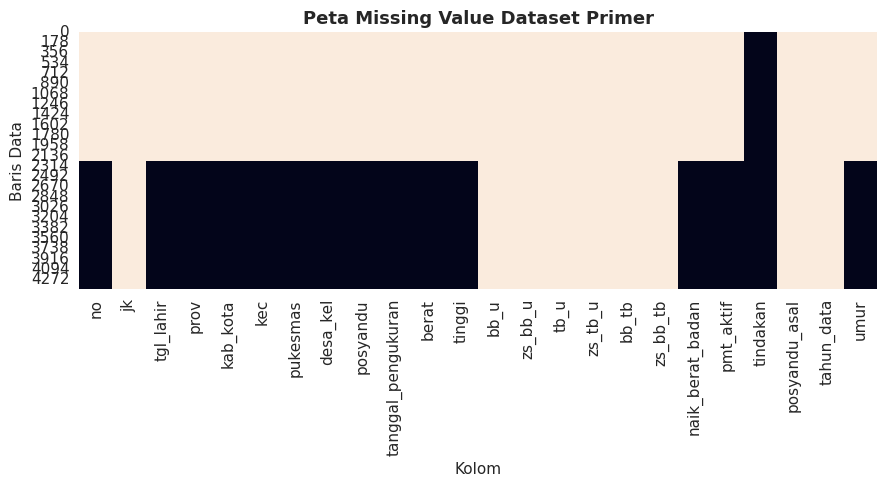

In [13]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Jumlah missing value per kolom:")
print(missing if len(missing) else "Tidak ada missing value.")

plt.figure(figsize=(9, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='rocket_r')
plt.title('Peta Missing Value Dataset Primer')
plt.xlabel('Kolom')
plt.ylabel('Baris Data')
plt.tight_layout()
plt.show()

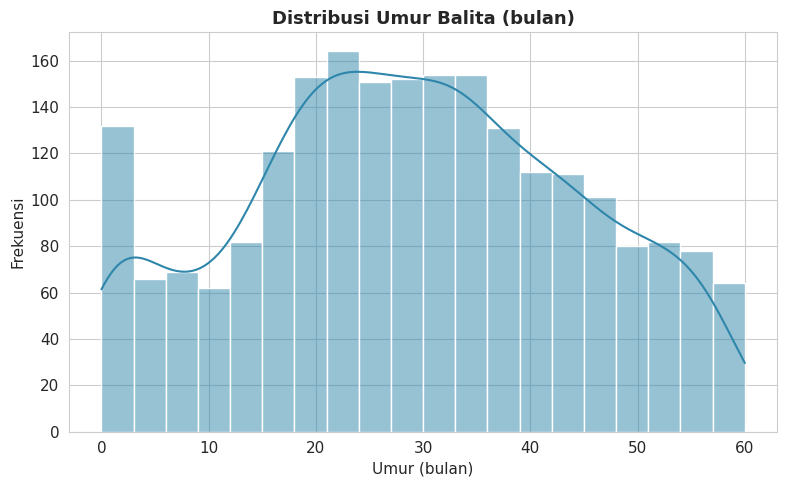

In [14]:
# 1. Tangani duplikasi nama kolom jika ada
if not df.columns.is_unique:
    print("Ditemukan duplikasi nama kolom. Melakukan deduplikasi...")
    df = df.loc[:, ~df.columns.duplicated()]

# 2. Hitung umur balita dalam bulan
if 'umur' not in df.columns:
    print("Menghitung kolom 'umur' dari tgl_lahir dan tanggal_pengukuran...")
    # Pastikan format datetime, tangani baris yang tidak valid dengan errors='coerce'
    df['tgl_lahir'] = pd.to_datetime(df['tgl_lahir'], errors='coerce')
    df['tanggal_pengukuran'] = pd.to_datetime(df['tanggal_pengukuran'], errors='coerce')

    # Hitung selisih bulan (menggunakan rata-rata hari dalam sebulan: 30.44)
    df['umur'] = ((df['tanggal_pengukuran'] - df['tgl_lahir']).dt.days / 30.44).apply(np.floor)

# Visualisasi Distribusi umur balita
plt.figure(figsize=(8, 5))
sns.histplot(df[KOL_UMUR].dropna(), bins=20, color='#2E86AB', kde=True, edgecolor='white')
plt.title('Distribusi Umur Balita (bulan)')
plt.xlabel('Umur (bulan)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

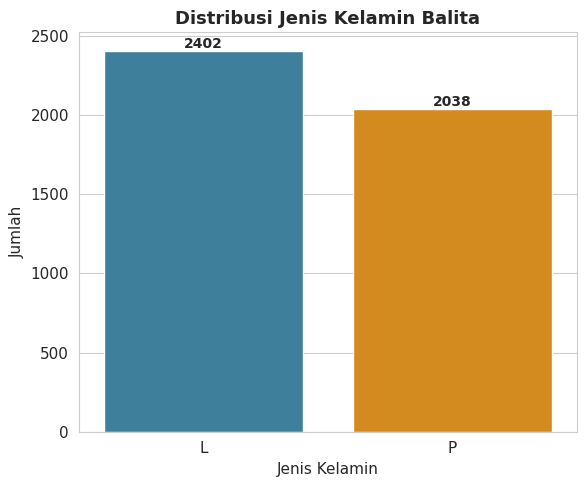

In [15]:
# Distribusi jenis kelamin
plt.figure(figsize=(6, 5))
ax = sns.countplot(x=KOL_JK, data=df, palette=['#2E86AB', '#F18F01'])
plt.title('Distribusi Jenis Kelamin Balita')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Jumlah')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

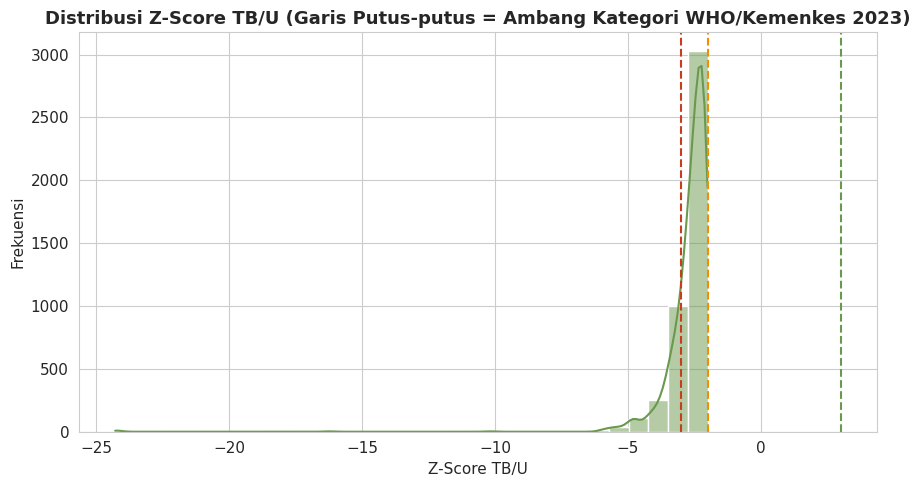

In [16]:
# Distribusi Z-Score TB/U (dasar pelabelan)
plt.figure(figsize=(9, 5))
sns.histplot(df[KOL_ZSCORE], bins=30, color='#6A994E', kde=True, edgecolor='white')
for batas, warna in [(-3, '#C73E1D'), (-2, '#F18F01'), (3, '#6A994E')]:
    plt.axvline(batas, color=warna, linestyle='--', linewidth=1.5)
plt.title('Distribusi Z-Score TB/U (Garis Putus-putus = Ambang Kategori WHO/Kemenkes 2023)')
plt.xlabel('Z-Score TB/U')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

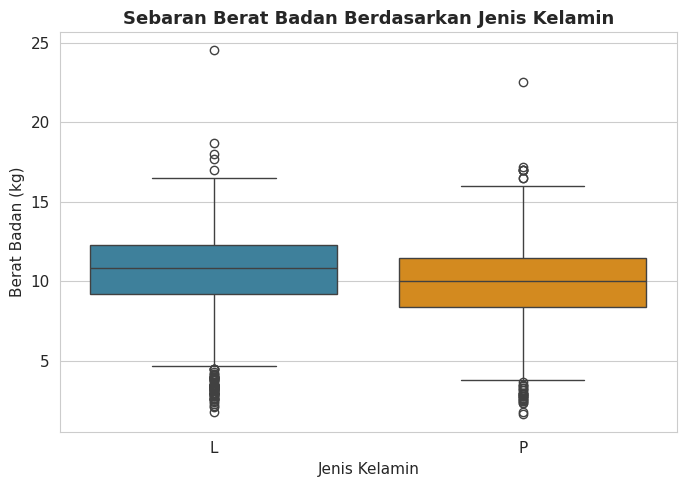

In [17]:
# Boxplot berat badan menurut jenis kelamin
plt.figure(figsize=(7, 5))
sns.boxplot(x=KOL_JK, y=KOL_BB, data=df, palette=['#2E86AB', '#F18F01'])
plt.title('Sebaran Berat Badan Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Berat Badan (kg)')
plt.tight_layout()
plt.show()

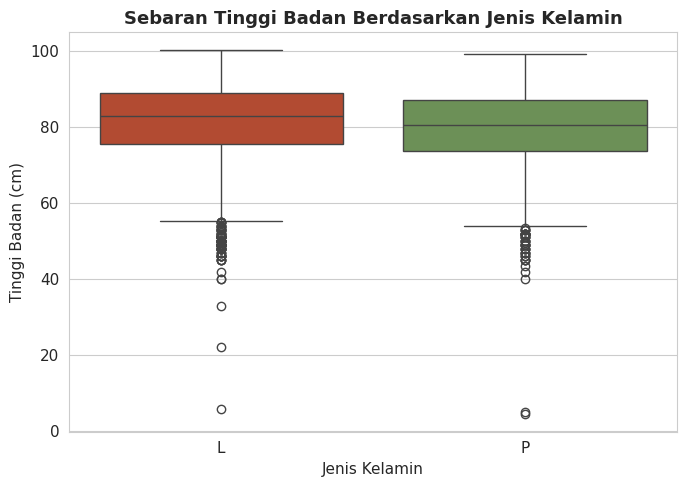

In [18]:
# Boxplot tinggi badan menurut jenis kelamin
plt.figure(figsize=(7, 5))
sns.boxplot(x=KOL_JK, y=KOL_TB, data=df, palette=['#C73E1D', '#6A994E'])
plt.title('Sebaran Tinggi Badan Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Tinggi Badan (cm)')
plt.tight_layout()
plt.show()

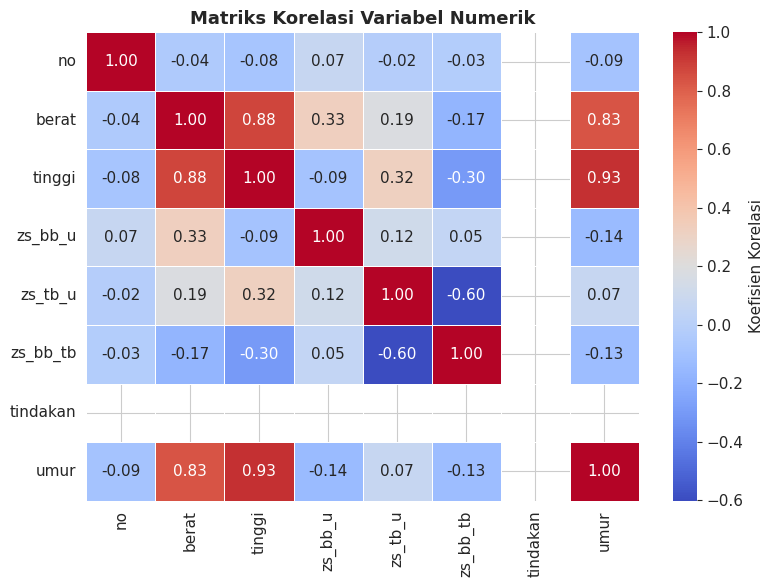

In [19]:
# Korelasi antar variabel numerik
kolom_numerik = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(8, 6))
sns.heatmap(df[kolom_numerik].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, cbar_kws={'label': 'Koefisien Korelasi'})
plt.title('Matriks Korelasi Variabel Numerik')
plt.tight_layout()
plt.show()

### 2.4 Visualisasi Antropometri Lanjutan (Kesehatan)
Bagian ini menambahkan analisis mendalam mengenai hubungan antar variabel fisik sesuai standar pemantauan pertumbuhan balita.

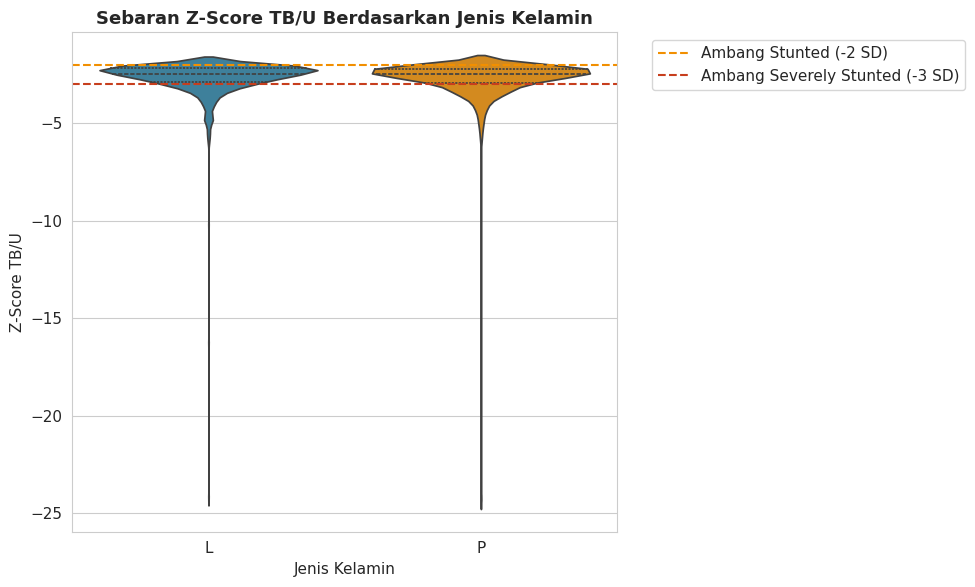

In [20]:
# 1. Distribusi Z-Score TB/U Berdasarkan Jenis Kelamin
plt.figure(figsize=(10, 6))
sns.violinplot(x=KOL_JK, y=KOL_ZSCORE, data=df, palette=['#2E86AB', '#F18F01'], inner='quartile')
plt.axhline(-2, color='#F18F01', linestyle='--', label='Ambang Stunted (-2 SD)')
plt.axhline(-3, color='#C73E1D', linestyle='--', label='Ambang Severely Stunted (-3 SD)')
plt.title('Sebaran Z-Score TB/U Berdasarkan Jenis Kelamin')
plt.xlabel('Jenis Kelamin')
plt.ylabel('Z-Score TB/U')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

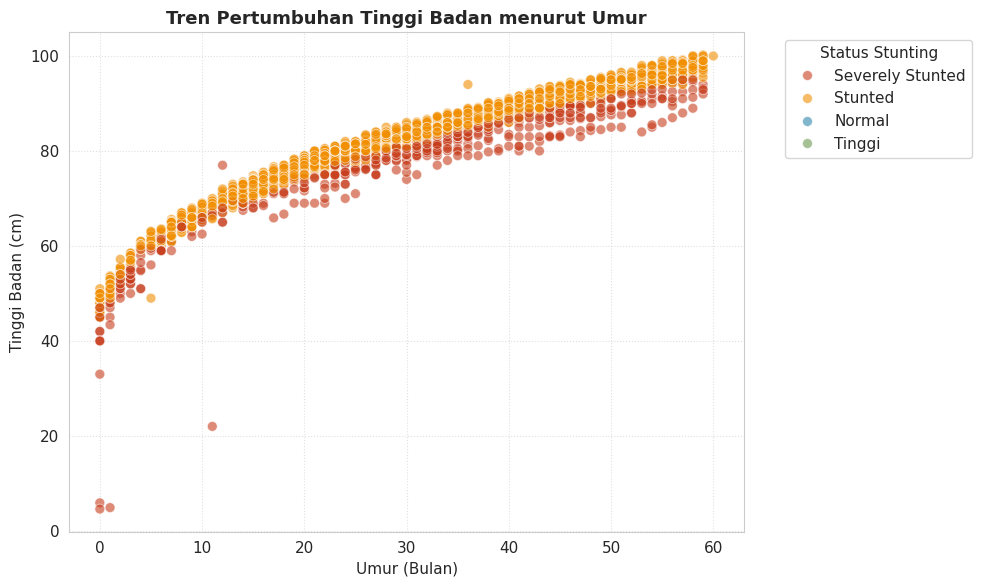

In [22]:
# --- FIX: Buat kolom status_stunting sementara untuk visualisasi jika belum ada ---
def label_stunting_temp(z):
    if pd.isna(z): return np.nan
    if z < -3: return 'Severely Stunted'
    elif -3 <= z < -2: return 'Stunted'
    elif -2 <= z <= 3: return 'Normal'
    else: return 'Tinggi'

if KOL_TARGET not in df.columns:
    df[KOL_TARGET] = df[KOL_ZSCORE].apply(label_stunting_temp)

# 2. Tren Pertumbuhan: Umur vs Tinggi Badan
plt.figure(figsize=(10, 6))
sns.scatterplot(x=KOL_UMUR, y=KOL_TB, hue=KOL_TARGET, data=df,
                palette=KATEGORI_WARNA, hue_order=KATEGORI_ORDER, alpha=0.6, s=50)

plt.title('Tren Pertumbuhan Tinggi Badan menurut Umur')
plt.xlabel('Umur (Bulan)')
plt.ylabel('Tinggi Badan (cm)')
plt.legend(title='Status Stunting', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 3️⃣ Data Preparation
*(BAB III — 3.3 Data Preparation)*
### 3.1 Relabeling — Standar WHO / Kemenkes 2023

Label status stunting dibentuk dari kolom Z-Score TB/U (`KOL_ZSCORE`) menggunakan ambang batas resmi berikut:

| Kategori | Rentang Z-Score |
|---|---|
| Severely Stunted | Z-Score < -3 SD |
| Stunted | -3 SD ≤ Z-Score < -2 SD |
| Normal | -2 SD ≤ Z-Score ≤ +3 SD |
| Tinggi | Z-Score > +3 SD |

*(Setara dengan BAB III — 3.3.3 Data Labeling)*

In [24]:
def label_stunting(z):
    if pd.isna(z):
        return np.nan
    elif z < -3:
        return 'Severely Stunted'
    elif -3 <= z < -2:
        return 'Stunted'
    elif -2 <= z <= 3:
        return 'Normal'
    else:  # z > 3
        return 'Tinggi'

df[KOL_TARGET] = df[KOL_ZSCORE].apply(label_stunting)

print("Distribusi label hasil relabeling:")
print(df[KOL_TARGET].value_counts())

Distribusi label hasil relabeling:
status_stunting
Stunted             3532
Severely Stunted     908
Name: count, dtype: int64


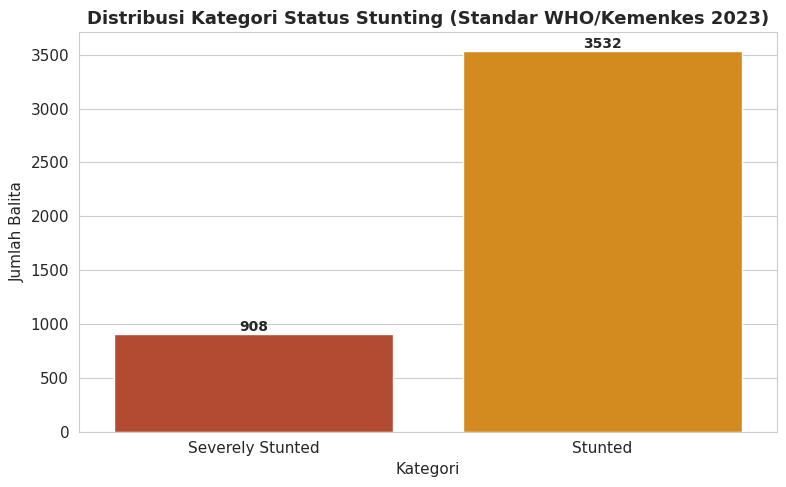

In [25]:
plt.figure(figsize=(8, 5))
urutan = [k for k in KATEGORI_ORDER if k in df[KOL_TARGET].unique()]
ax = sns.countplot(x=KOL_TARGET, data=df, order=urutan,
                    palette=[KATEGORI_WARNA[k] for k in urutan])
plt.title('Distribusi Kategori Status Stunting (Standar WHO/Kemenkes 2023)')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Balita')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.2 Cleaning, Encoding, Normalisasi
*(BAB III — 3.3.1 Data Integration & 3.3.2 Data Cleaning, 3.3.4 Data Transformation)*

In [27]:
import os
import joblib

# --- 1. Persiapan Folder Aset ---
os.makedirs('models', exist_ok=True)
os.makedirs('assets', exist_ok=True)
os.makedirs('data', exist_ok=True)

# --- 2. Integrasi & Fitur ---
# FIX: Definisikan list FITUR sebelum digunakan
FITUR = [KOL_UMUR, KOL_JK, KOL_BB, KOL_TB]

df_clean = df[FITUR + [KOL_TARGET]].copy()
print(f'Fitur yang digunakan: {FITUR}')

# --- 3. Penanganan Missing Values (Imputasi Otomatis) ---
for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        if df_clean[col].dtype in ['float64', 'int64']:
            med = df_clean[col].median()
            df_clean[col].fillna(med, inplace=True)
            print(f'  \u2705 {col}: missing diisi median={med:.2f}')
        else:
            # Untuk data kategorikal (seperti JK), ambil modus
            mod = df_clean[col].mode()[0]
            df_clean[col].fillna(mod, inplace=True)
            print(f'  \u2705 {col}: missing diisi modus={mod}')

# --- 4. Hapus Duplikat ---
n_dup = df_clean.duplicated().sum()
if n_dup > 0:
    df_clean = df_clean.drop_duplicates()
    print(f'\u2705 {n_dup:,} duplikat dihapus')

print(f'Jumlah baris setelah cleaning: {len(df_clean)}')
display(df_clean.head())

Fitur yang digunakan: ['umur', 'jk', 'berat', 'tinggi']
  ✅ umur: missing diisi median=29.00
  ✅ berat: missing diisi median=10.50
  ✅ tinggi: missing diisi median=81.50
✅ 2,326 duplikat dihapus
Jumlah baris setelah cleaning: 2114


,umur,jk,berat,tinggi,status_stunting
0,44.0,L,13.1,90.0,Stunted
1,39.0,P,13.5,89.0,Stunted
2,17.0,L,9.1,75.5,Stunted
3,0.0,L,3.2,50.0,Stunted
4,20.0,P,9.3,77.0,Stunted


In [28]:
# --- 5. Encoding Label ---
# Pastikan kolom JK tersedia di df_clean dari df asli jika belum ada
if KOL_JK not in df_clean.columns and KOL_JK in df.columns:
    df_clean[KOL_JK] = df.loc[df_clean.index, KOL_JK]

# Encoding Jenis Kelamin
le_jk = LabelEncoder()
df_clean['jk_encoded'] = le_jk.fit_transform(df_clean[KOL_JK].astype(str).str.upper())
print(f'Encoding JK: {dict(zip(le_jk.classes_, le_jk.transform(le_jk.classes_)))}')

# Encoding Target
le_target = LabelEncoder()
# Gunakan urutan KATEGORI_ORDER agar index numerik konsisten
le_target.fit(KATEGORI_ORDER)
df_clean[KOL_TARGET + '_encoded'] = le_target.transform(df_clean[KOL_TARGET])

print('\nMapping label target:')
for i, k in enumerate(le_target.classes_):
    print(f'  {i} -> {k}')

# Update X dan y
# Pastikan fitur yang digunakan adalah versi yang sudah di-encode
FITUR_FINAL = ['umur', 'jk_encoded', 'berat', 'tinggi']
X = df_clean[FITUR_FINAL].copy()
y = df_clean[KOL_TARGET + '_encoded'].values

# --- 6. Normalisasi ---
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

# --- 7. Simpan Aset ---
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_target, 'models/label_encoder_target.pkl')
joblib.dump(le_jk, 'models/label_encoder_jk.pkl')

print('\n✅ Aset (scaler & encoders) berhasil disimpan di folder /models')

Encoding JK: {'L': np.int64(0), 'P': np.int64(1)}

Mapping label target:
  0 -> Normal
  1 -> Severely Stunted
  2 -> Stunted
  3 -> Tinggi

✅ Aset (scaler & encoders) berhasil disimpan di folder /models


In [29]:
# --- Normalisasi fitur numerik ---
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=FITUR)
X_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
umur,2114.0,7.058372e-17,1.000237,-1.879443,-0.714564,-0.002694,0.773892,2.003486
jk,2114.0,9.411162e-17,1.000237,-0.928738,-0.928738,-0.928738,1.076729,1.076729
berat,2114.0,-3.025016e-17,1.000237,-3.062449,-0.507778,0.103903,0.643622,5.141281
tinggi,2114.0,-1.151187e-16,1.000237,-6.077420,-0.393835,0.177958,0.685096,1.648861


### 3.3 SMOTETomek & Data Splitting
*(BAB III — 3.3.5 Data Splitting & 3.3.6 Data Balancing)*

Data displit terlebih dahulu, kemudian **SMOTETomek** hanya diterapkan pada data latih agar tidak terjadi *data leakage* ke data uji.

In [30]:
# ============================================================
# Rasio pembagian data — silakan ganti sesuai kebutuhan
# 0.25 -> split 75:25 (default)
# 0.20 -> split 80:20
# 0.50 -> split 50:50
# ============================================================
RASIO_TEST = 0.25

# PERBAIKAN: Pastikan y_encoded sinkron dengan jumlah baris X_scaled
y_encoded_clean = df_clean[KOL_TARGET + '_encoded'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded_clean,
    test_size=RASIO_TEST,
    random_state=RANDOM_STATE,
    stratify=y_encoded_clean
)

print(f"Split data -> train: {X_train.shape[0]} data | test: {X_test.shape[0]} data "
      f"(rasio {(1-RASIO_TEST)*100:.0f}:{RASIO_TEST*100:.0f})")

Split data -> train: 1585 data | test: 529 data (rasio 75:25)


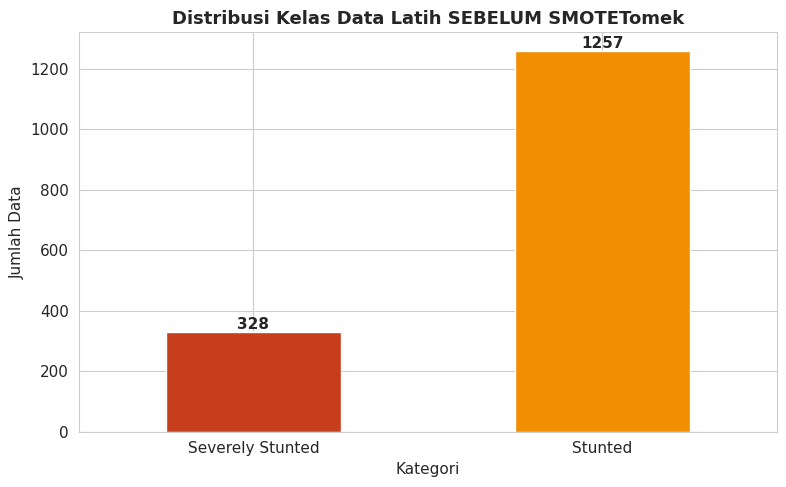

In [31]:
# Distribusi kelas SEBELUM balancing (data latih)
plt.figure(figsize=(8, 5))

# Hitung frekuensi dan hanya ambil kategori yang ada nilainya (bukan NaN)
sebelum = pd.Series(y_train).map(dict(enumerate(le_target.classes_))).value_counts()
# Pastikan urutan tetap sesuai KATEGORI_ORDER tapi hanya untuk yang ada datanya
urutan_ada = [k for k in KATEGORI_ORDER if k in sebelum.index]
sebelum = sebelum.reindex(urutan_ada)

ax = sebelum.plot(kind='bar', color=[KATEGORI_WARNA[k] for k in urutan_ada])

plt.title('Distribusi Kelas Data Latih SEBELUM SMOTETomek')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)

# Tambahkan label angka di atas bar
for i, v in enumerate(sebelum.values):
    if not pd.isna(v):
        plt.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [32]:
# --- Balancing dengan SMOTETomek (hanya pada data latih) ---
smt = SMOTETomek(random_state=RANDOM_STATE)
X_train_bal, y_train_bal = smt.fit_resample(X_train, y_train)

print("Ukuran data latih sebelum balancing:", X_train.shape)
print("Ukuran data latih sesudah balancing :", X_train_bal.shape)

Ukuran data latih sebelum balancing: (1585, 4)
Ukuran data latih sesudah balancing : (2472, 4)


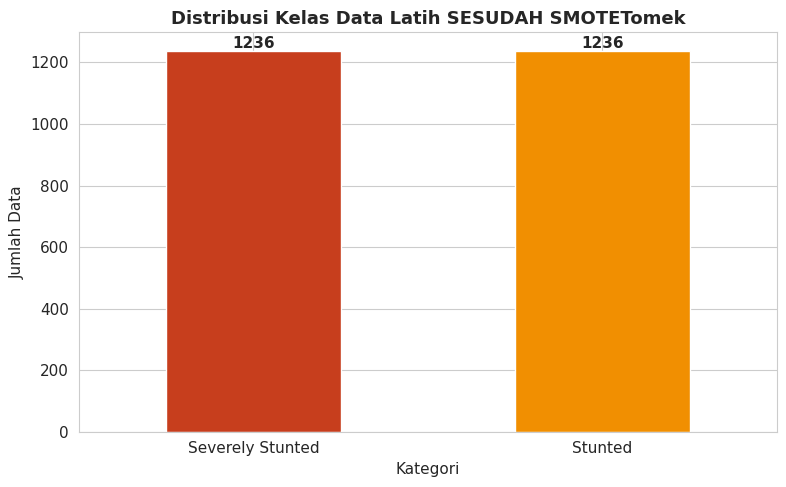

In [33]:
# Distribusi kelas SESUDAH balancing (data latih)
plt.figure(figsize=(8, 5))

# Hitung frekuensi setelah balancing
sesudah = pd.Series(y_train_bal).map(dict(enumerate(le_target.classes_))).value_counts()

# Filter urutan kategori agar hanya menyertakan yang memiliki data
urutan_ada_bal = [k for k in KATEGORI_ORDER if k in sesudah.index]
sesudah = sesudah.reindex(urutan_ada_bal)

ax = sesudah.plot(kind='bar', color=[KATEGORI_WARNA[k] for k in urutan_ada_bal])

plt.title('Distribusi Kelas Data Latih SESUDAH SMOTETomek')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Data')
plt.xticks(rotation=0)

# Tambahkan label angka di atas bar (hanya jika nilainya valid)
for i, v in enumerate(sesudah.values):
    if not pd.isna(v):
        plt.text(i, v, str(int(v)), ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 4️⃣ Modeling
*(BAB III — 3.4 Modeling: 3.4.1 Pemilihan Algoritma, 3.4.2 Optimasi Hyperparameter, 3.4.3 Pelatihan Model)*

Dua algoritma dipilih berdasarkan literatur klasifikasi status gizi: **Random Forest** (ensemble bagging, tahan terhadap overfitting & data tidak seimbang) dan **XGBoost** (ensemble boosting, akurasi tinggi pada data tabular). Optimasi hyperparameter dilakukan dengan **GridSearchCV**.
### 4.1 Random Forest + GridSearchCV

In [34]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced')

grid_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

grid_rf.fit(X_train_bal, y_train_bal)

print("Parameter terbaik Random Forest:", grid_rf.best_params_)
print(f"Skor F1-macro terbaik (CV): {grid_rf.best_score_:.4f}")

model_rf = grid_rf.best_estimator_

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Parameter terbaik Random Forest: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Skor F1-macro terbaik (CV): 0.9587


### 4.2 XGBoost + GridSearchCV

In [35]:
from sklearn.preprocessing import LabelEncoder

# --- PERBAIKAN: Re-mapping label agar kontigu (0, 1, ...) ---
# XGBoost memerlukan label yang dimulai dari 0 tanpa ada angka yang melompat.
le_train = LabelEncoder()
y_train_bal_contig = le_train.fit_transform(y_train_bal)
y_test_contig = le_train.transform(y_test)

param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y_train_bal_contig)),
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    use_label_encoder=False
)

grid_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid_xgb,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print("Memulai Grid Search XGBoost dengan label yang sudah diperbaiki...")
grid_xgb.fit(X_train_bal, y_train_bal_contig)

print("Parameter terbaik XGBoost:", grid_xgb.best_params_)
print(f"Skor F1-macro terbaik (CV): {grid_xgb.best_score_:.4f}")

model_xgb = grid_xgb.best_estimator_

# Simpan le_train untuk digunakan saat evaluasi (inverse_transform)
joblib.dump(le_train, 'models/label_encoder_train_internal.pkl')

Memulai Grid Search XGBoost dengan label yang sudah diperbaiki...
Fitting 5 folds for each of 54 candidates, totalling 270 fits
Parameter terbaik XGBoost: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Skor F1-macro terbaik (CV): nan


['models/label_encoder_train_internal.pkl']

## 5️⃣ Evaluation
*(BAB III — 3.5 Evaluation: 3.5.1 Metrik Evaluasi, 3.5.2 Confusion Matrix, 3.5.3 Classification Report)*
### 5.1 Prediksi & Metrik

In [36]:
# --- 1. Prediksi Random Forest (Langsung Label) ---
y_pred_rf = model_rf.predict(X_test)

# --- 2. Prediksi XGBoost (Probabilitas -> Label Kontigu -> Label Asli) ---
y_pred_xgb_raw = model_xgb.predict(X_test)
if len(y_pred_xgb_raw.shape) > 1:
    y_pred_xgb_contig = np.argmax(y_pred_xgb_raw, axis=1)
else:
    y_pred_xgb_contig = y_pred_xgb_raw

y_pred_xgb = le_train.inverse_transform(y_pred_xgb_contig)

def hitung_metrik(nama, y_true, y_pred):
    return {
        'Model': nama,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-Score (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

hasil_rf = hitung_metrik('Random Forest', y_test, y_pred_rf)
hasil_xgb = hitung_metrik('XGBoost', y_test, y_pred_xgb)

# --- PERBAIKAN: Identifikasi kelas yang benar-benar ada di y_test ---
classes_in_test = np.unique(np.concatenate([y_test, y_pred_rf, y_pred_xgb]))
target_names_dynamic = [le_target.classes_[i] for i in classes_in_test]

print("=== Classification Report: Random Forest ===")
print(classification_report(y_test, y_pred_rf, labels=classes_in_test, target_names=target_names_dynamic, zero_division=0))

print("\n=== Classification Report: XGBoost ===")
print(classification_report(y_test, y_pred_xgb, labels=classes_in_test, target_names=target_names_dynamic, zero_division=0))

=== Classification Report: Random Forest ===
                  precision    recall  f1-score   support

Severely Stunted       0.81      0.81      0.81       109
         Stunted       0.95      0.95      0.95       420

        accuracy                           0.92       529
       macro avg       0.88      0.88      0.88       529
    weighted avg       0.92      0.92      0.92       529


=== Classification Report: XGBoost ===
                  precision    recall  f1-score   support

Severely Stunted       0.44      0.74      0.55       109
         Stunted       0.92      0.75      0.83       420

        accuracy                           0.75       529
       macro avg       0.68      0.75      0.69       529
    weighted avg       0.82      0.75      0.77       529



### 5.2 Perbandingan & Model Terbaik

In [37]:
df_perbandingan = pd.DataFrame([hasil_rf, hasil_xgb]).set_index('Model')
df_perbandingan = df_perbandingan.round(4)
display(df_perbandingan)

model_terbaik_nama = df_perbandingan['F1-Score (macro)'].idxmax()
model_terbaik = model_rf if model_terbaik_nama == 'Random Forest' else model_xgb
print(f"\n🏆 Model terbaik berdasarkan F1-Score (macro): {model_terbaik_nama}")

,Accuracy,Precision (macro),Recall (macro),F1-Score (macro)
Model,,,,
Random Forest,0.9225,0.8825,0.8799,0.8812
XGBoost,0.7524,0.6795,0.7489,0.6908



🏆 Model terbaik berdasarkan F1-Score (macro): Random Forest


### 5.3 Confusion Matrix

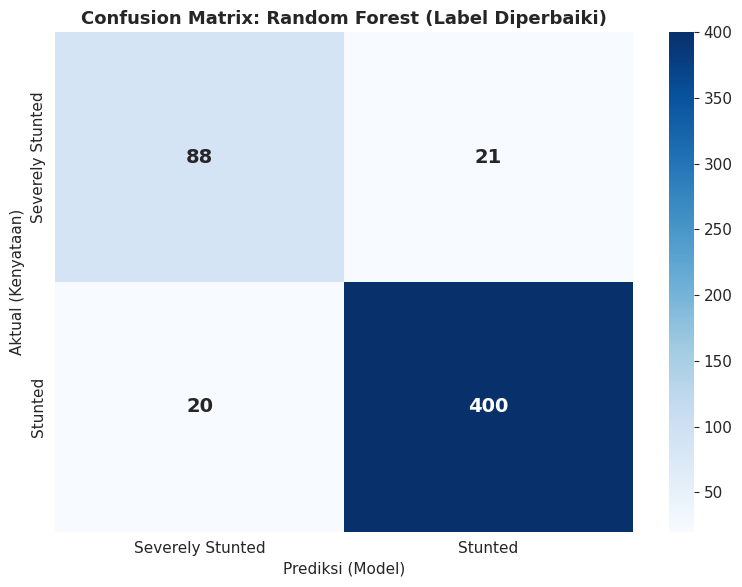

In [41]:
# --- Perbaikan Confusion Matrix Random Forest ---
# Ambil label kategori yang benar-benar ada di y_test dan y_pred
labels_rf = np.unique(np.concatenate([y_test, y_pred_rf]))
labels_names_rf = [le_target.classes_[i] for i in labels_rf]

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=labels_rf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_names_rf,
            yticklabels=labels_names_rf,
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Prediksi (Model)')
plt.ylabel('Aktual (Kenyataan)')
plt.tight_layout()
plt.show()

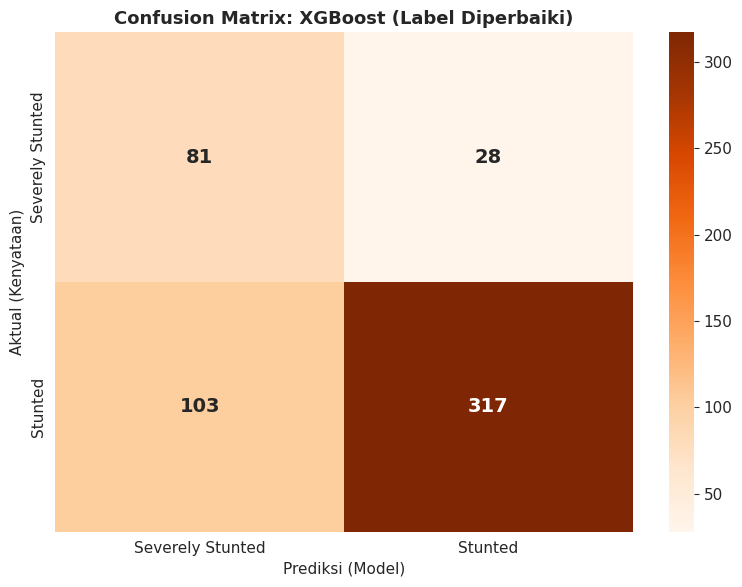

In [42]:
# --- Perbaikan Confusion Matrix XGBoost ---
# Ambil label kategori yang benar-benar ada di y_test dan y_pred
labels_xgb = np.unique(np.concatenate([y_test, y_pred_xgb]))
labels_names_xgb = [le_target.classes_[i] for i in labels_xgb]

cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=labels_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_names_xgb,
            yticklabels=labels_names_xgb,
            annot_kws={'size': 14, 'weight': 'bold'})

plt.title('Confusion Matrix: XGBoost')
plt.xlabel('Prediksi (Model)')
plt.ylabel('Aktual (Kenyataan)')
plt.tight_layout()
plt.show()

### 5.4 Feature Importance

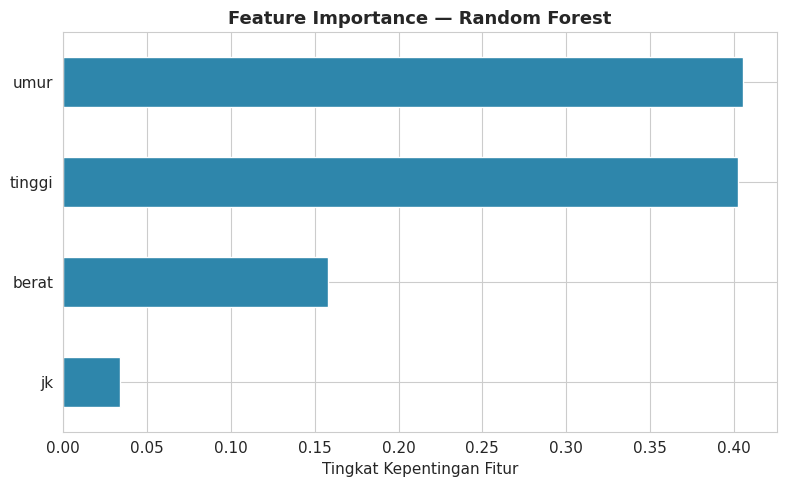

In [43]:
# Feature Importance - Random Forest
fi_rf = pd.Series(model_rf.feature_importances_, index=FITUR).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
fi_rf.plot(kind='barh', color='#2E86AB')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.tight_layout()
plt.show()

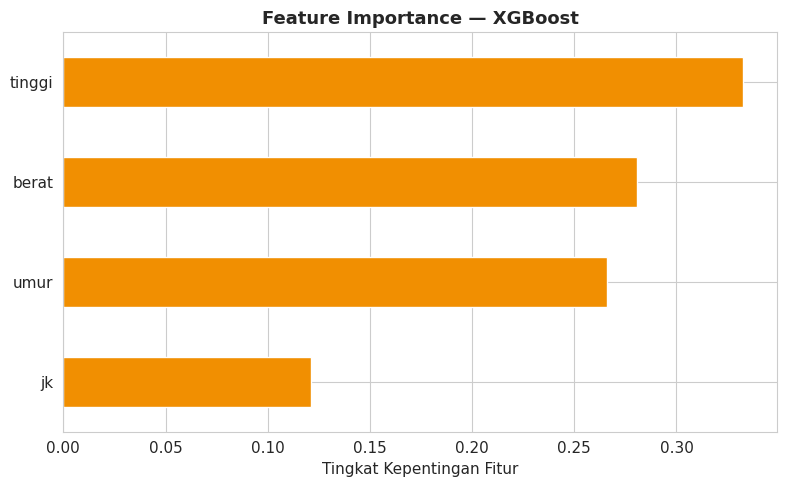

In [44]:
# Feature Importance - XGBoost
fi_xgb = pd.Series(model_xgb.feature_importances_, index=FITUR).sort_values(ascending=True)
plt.figure(figsize=(8, 5))
fi_xgb.plot(kind='barh', color='#F18F01')
plt.title('Feature Importance — XGBoost')
plt.xlabel('Tingkat Kepentingan Fitur')
plt.tight_layout()
plt.show()

### 5.5 ROC Curve (Multi-class, One-vs-Rest)

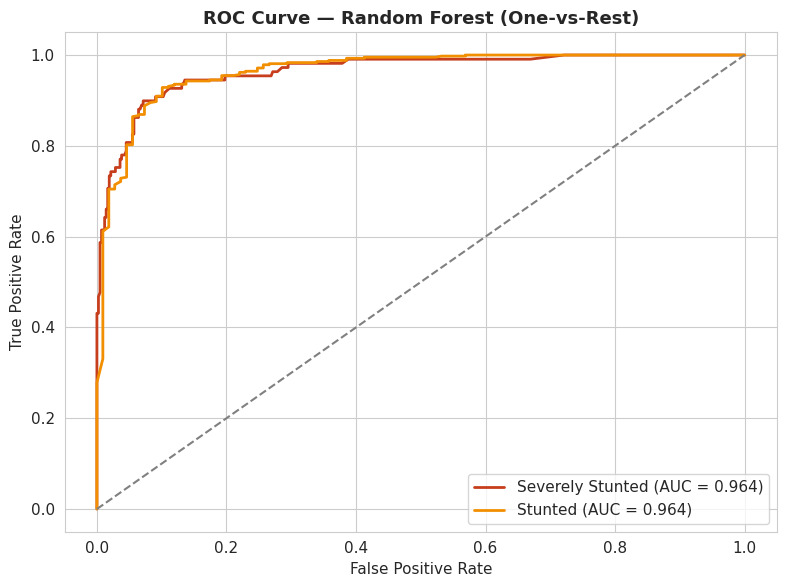

In [45]:
y_test_bin = label_binarize(y_test, classes=list(range(len(le_target.classes_))))
proba_rf = model_rf.predict_proba(X_test)

# --- PERBAIKAN: Hanya iterasi pada index kelas yang ada di y_test ---
plt.figure(figsize=(8, 6))
for i in classes_in_test:
    kategori = le_target.classes_[i]
    # Cari posisi kolom di proba_rf yang sesuai dengan urutan kelas di model
    # Karena model hanya punya 2 kelas, kita ambil index relatifnya
    idx_relatif = list(model_rf.classes_).index(i)

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_rf[:, idx_relatif])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=KATEGORI_WARNA[kategori], linewidth=2,
             label=f'{kategori} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve — Random Forest (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

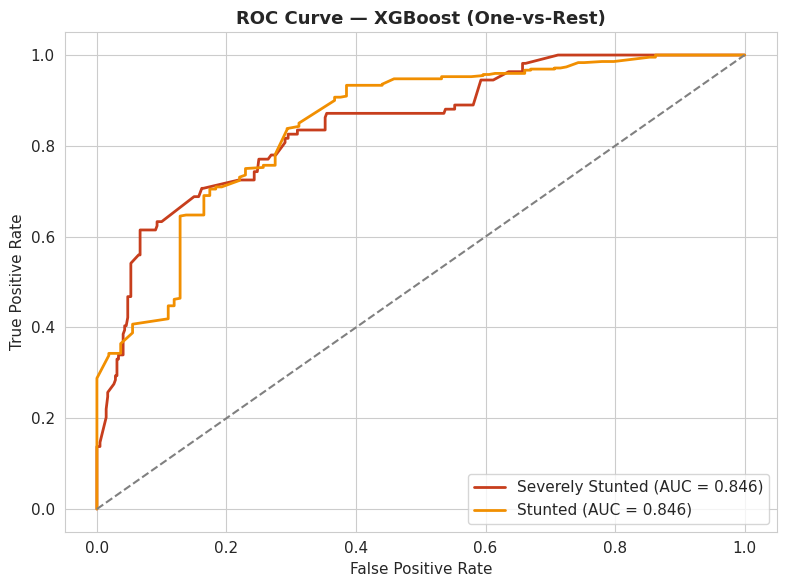

In [46]:
proba_xgb = model_xgb.predict_proba(X_test)

plt.figure(figsize=(8, 6))
# --- PERBAIKAN: Konversi label asli ke label internal XGBoost ---
for i in classes_in_test:
    kategori = le_target.classes_[i]

    # Konversi label asli (misal 2) ke label internal XGBoost (misal 1)
    label_internal = le_train.transform([i])[0]

    # Cari posisi kolom di proba_xgb berdasarkan label internal
    idx_relatif = list(model_xgb.classes_).index(label_internal)

    # Gunakan y_test_bin yang sudah dibuat sebelumnya (berdasarkan label asli)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba_xgb[:, idx_relatif])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=KATEGORI_WARNA[kategori], linewidth=2,
             label=f'{kategori} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.title('ROC Curve — XGBoost (One-vs-Rest)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 5.6 Grafik Perbandingan Metrik

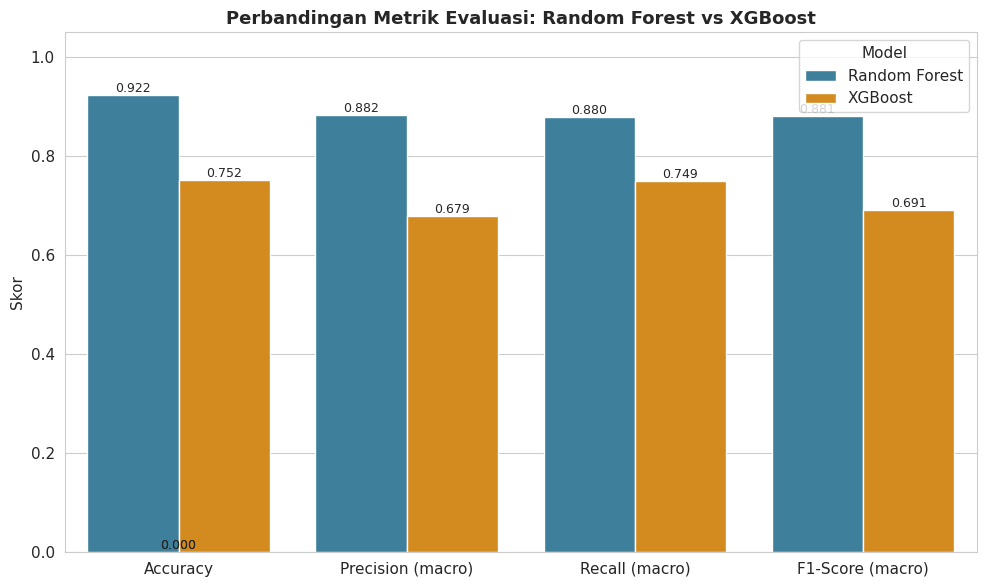

In [47]:
metrik_plot = df_perbandingan.reset_index().melt(id_vars='Model', var_name='Metrik', value_name='Skor')

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=metrik_plot, x='Metrik', y='Skor', hue='Model',
                  palette=[MODEL_WARNA['Random Forest'], MODEL_WARNA['XGBoost']])
plt.title('Perbandingan Metrik Evaluasi: Random Forest vs XGBoost')
plt.ylim(0, 1.05)
plt.ylabel('Skor')
plt.xlabel('')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=9)
plt.legend(title='Model')
plt.tight_layout()
plt.show()

## 6️⃣ Validasi Data Primer

> **Perlu tidaknya tahap ini:** Untuk data **primer** (biasanya berjumlah relatif terbatas dibanding data sekunder), performa pada satu kali *train-test split* bisa terlalu optimis/pesimis tergantung kebetulan pembagian data. Oleh karena itu, tahap ini **direkomendasikan** untuk menguji **stabilitas & generalisasi** model terbaik menggunakan **Stratified K-Fold Cross Validation** pada keseluruhan data (sebelum split), sehingga hasil evaluasi lebih dapat dipertanggungjawabkan secara metodologis.

In [48]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# --- PERBAIKAN: Gunakan label yang sinkron dengan X_scaled (dari df_clean) ---
y_cv = df_clean[KOL_TARGET + '_encoded'].values

cv_scores = cross_val_score(model_terbaik, X_scaled, y_cv, cv=skf, scoring='f1_macro', n_jobs=-1)

print(f"Hasil Stratified 5-Fold Cross Validation — Model: {model_terbaik_nama}")
print("Skor F1-macro tiap fold:", np.round(cv_scores, 4))
print(f"Rata-rata: {cv_scores.mean():.4f} | Standar Deviasi: {cv_scores.std():.4f}")

Hasil Stratified 5-Fold Cross Validation — Model: Random Forest
Skor F1-macro tiap fold: [0.8988 0.8717 0.9041 0.8734 0.8775]
Rata-rata: 0.8851 | Standar Deviasi: 0.0136


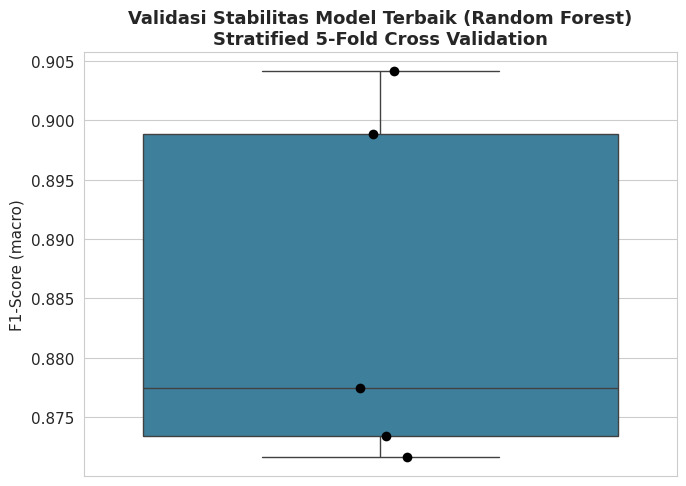

In [49]:
plt.figure(figsize=(7, 5))
sns.boxplot(y=cv_scores, color=MODEL_WARNA.get(model_terbaik_nama, '#2E86AB'))
sns.stripplot(y=cv_scores, color='black', size=7, jitter=0.05)
plt.title(f'Validasi Stabilitas Model Terbaik ({model_terbaik_nama})\nStratified 5-Fold Cross Validation')
plt.ylabel('F1-Score (macro)')
plt.tight_layout()
plt.show()

**Interpretasi:** Nilai standar deviasi yang kecil antar-fold mengindikasikan bahwa performa model **konsisten** dan tidak terlalu bergantung pada satu skema pembagian data tertentu, sehingga model cukup layak untuk dilanjutkan ke tahap deployment.

## 7️⃣ Download Model & Aset untuk Streamlit
*(mendukung BAB III — 3.6 Deployment)*

Menyimpan model terbaik beserta seluruh objek praproses (scaler, label encoder) agar dapat langsung dipakai pada aplikasi Streamlit (VS Code) tanpa perlu melatih ulang.

In [50]:
OUTPUT_DIR = '/content/aset_streamlit'
os.makedirs(OUTPUT_DIR, exist_ok=True)

joblib.dump(model_terbaik, os.path.join(OUTPUT_DIR, 'model_terbaik.pkl'))
joblib.dump(model_rf, os.path.join(OUTPUT_DIR, 'model_random_forest.pkl'))
joblib.dump(model_xgb, os.path.join(OUTPUT_DIR, 'model_xgboost.pkl'))
joblib.dump(scaler, os.path.join(OUTPUT_DIR, 'scaler.pkl'))
joblib.dump(le_jk, os.path.join(OUTPUT_DIR, 'label_encoder_jk.pkl'))
joblib.dump(le_target, os.path.join(OUTPUT_DIR, 'label_encoder_target.pkl'))

# Simpan metadata (nama fitur, kategori, metrik) untuk dipakai di Streamlit
metadata = {
    'fitur': FITUR,
    'kategori': list(le_target.classes_),
    'model_terbaik': model_terbaik_nama,
    'metrik_rf': hasil_rf,
    'metrik_xgb': hasil_xgb,
}
with open(os.path.join(OUTPUT_DIR, 'metadata.json'), 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print("Aset tersimpan pada:", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))

Aset tersimpan pada: /content/aset_streamlit
['scaler.pkl', 'model_terbaik.pkl', 'model_xgboost.pkl', 'label_encoder_jk.pkl', 'label_encoder_target.pkl', 'metadata.json', 'model_random_forest.pkl']


In [51]:
import shutil
from google.colab import files

zip_path = '/content/aset_streamlit.zip'
shutil.make_archive('/content/aset_streamlit', 'zip', OUTPUT_DIR)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 8️⃣ Kesimpulan

- Model klasifikasi status stunting balita berhasil dibangun menggunakan **Random Forest** dan **XGBoost** dengan optimasi hyperparameter melalui **GridSearchCV**.
- Pelabelan mengikuti standar **WHO/Kemenkes 2023** berbasis Z-Score TB/U (4 kelas: Severely Stunted, Stunted, Normal, Tinggi).
- Ketidakseimbangan kelas ditangani menggunakan **SMOTETomek** pada data latih.
- Berdasarkan metrik Accuracy, Precision, Recall, dan F1-Score (macro), model **`{{model_terbaik}}`** menunjukkan performa terbaik pada data uji, serta terkonfirmasi stabil melalui **Stratified K-Fold Cross Validation**.
- Model terbaik beserta aset praproses (scaler & label encoder) telah diekspor untuk tahap **Deployment berbasis Streamlit**.

### 🔗 Pemetaan Notebook terhadap Struktur BAB III

| Bagian Notebook | Sub-Bab III |
|---|---|
| 1. Business Understanding | 3.1 Business Understanding |
| 2. Data Understanding | 3.2 Data Understanding |
| 3.2 Cleaning, Encoding | 3.3.1 Data Integration, 3.3.2 Data Cleaning |
| 3.1 Relabeling | 3.3.3 Data Labeling |
| 3.2 Normalisasi/Encoding | 3.3.4 Data Transformation |
| 3.3 Split Data | 3.3.5 Data Splitting |
| 3.3 SMOTETomek | 3.3.6 Data Balancing |
| 4.1 & 4.2 (pemilihan RF/XGB) | 3.4.1 Pemilihan Algoritma |
| 4.1 & 4.2 (GridSearchCV) | 3.4.2 Optimasi Hyperparameter |
| 4.1 & 4.2 (fit model) | 3.4.3 Pelatihan Model |
| 7. Download Model | 3.4.4 Penyimpanan Model Terbaik |
| 5.1, 5.2, 5.6 | 3.5.1 Metrik Evaluasi |
| 5.3 | 3.5.2 Confusion Matrix |
| 5.1 (classification_report) | 3.5.3 Classification Report |
| *(dilanjutkan di luar notebook — VS Code)* | 3.6 Deployment (UML, Interface, Dashboard Streamlit, Pengujian Sistem) |

> **Catatan Deployment (3.6):** Rancangan UML, rancangan interface, implementasi dashboard Streamlit, dan pengujian sistem (3.6.1–3.6.2) dikerjakan pada proyek terpisah berbasis **VS Code (Streamlit)** menggunakan aset model yang diunduh dari Bagian 7 notebook ini.